## Visualization of EPO prediction error

In this notebook, we estimate the final prediction by averaging the EPO values `EPOs_1` and `EPOs_2` to get a single predicted EPO for a given treatment level. This runs over five datasets: Vahid's linear, Vahid's nonlinear, EconML Ex 1, Debt Loss, and ADMIT synthetic. Run the notebook to create figures and output files.

Fix a dataset. For each `N = N_DISC`, we have an approximation to the DRF given by CausalPFN, which is a linear interpolation at the `N` treatment values. We use `scipy.interpolate.interp1d` (legacy) to define the linear interpolations from the data. No extrapolation is necessary, since `0` and `1` are in `discrete_treatment_levels`. For each dataset and `N` value, we estimate the RMSE on a fixed `T`-mesh, `rmse_calc_t_mesh`. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from scipy.interpolate import interp1d

In [2]:
## Fix the t-mesh on which to evaluate RMSE
rmse_calc_t_mesh = np.linspace(0, 1, 100)

In [3]:
## Load DataFrames

df_debt = pd.read_csv(
    "../output/11-17_to_11-18/EPO_df_debt-loss_11-17_14h2m.csv",
    index_col=[0, 1]
)
df_econML = pd.read_csv(
    "../output/11-17_to_11-18/EPO_df_econ-ML-ex1_11-17_14h30m.csv",
    index_col=[0, 1]
)
df_linear = pd.read_csv(
    "../output/11-17_to_11-18/EPO_df_vahid-linear_11-17_12h51m.csv",
    index_col=[0, 1]
)
df_nonlin = pd.read_csv(
    "../output/11-17_to_11-18/EPO_df_vahid-nonlinear_11-17_12h34m.csv",
    index_col=[0, 1]
)
df_admit = pd.read_csv(
    "../output/11-17_to_11-18/EPO_df_ADMIT-synthetic_11-17_15h54m.csv",
    index_col=[0, 1]
)

In [4]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

In [5]:
# For file naming purposes
month = datetime.datetime.now().month
date = datetime.datetime.now().day
hour = datetime.datetime.now().hour
minute = datetime.datetime.now().minute
date_string = f"{month}-{date}_{hour}h{minute}m"
file_location = "../output"

## Dataset 1: Linear DRF

In [6]:
df = df_linear
data_name = "vahid-linear"
N_max = df.index[-1][0]

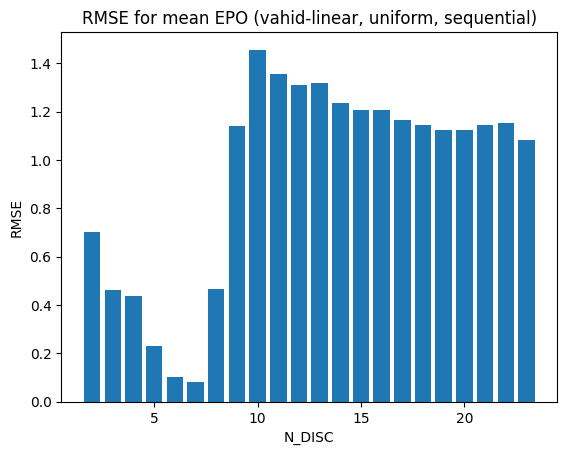

In [7]:
# RMSE calculation on the average EPO

def drf_linear(t): return 3.5 + 3 * t # true dose-response function

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_linear(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO ({data_name}, uniform, sequential)")
plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

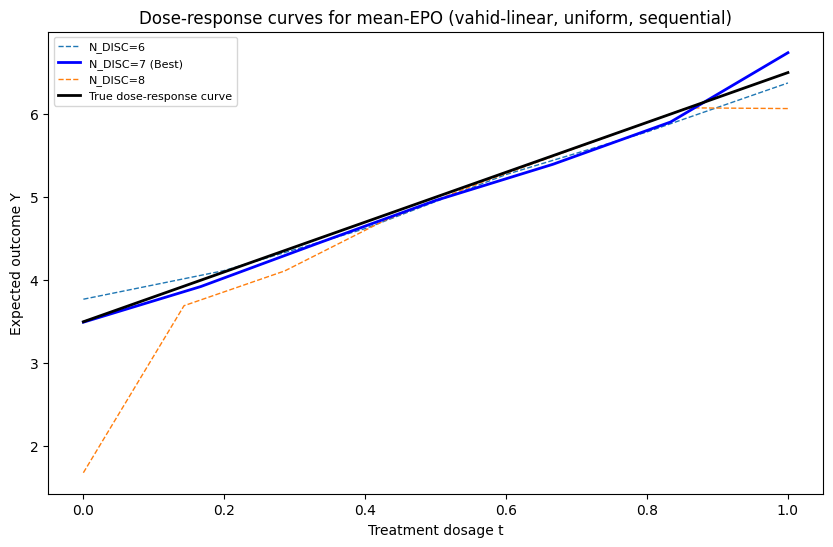

In [8]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [6, 7, 8]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
def linear_drf(t): return 3.5 + 3 * t
t_mesh = np.linspace(0, 1, 100)
y_true = linear_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO ({data_name}, uniform, sequential)")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 2: Nonlinear DRF

In [9]:
df = df_nonlin
data_name = "vahid-nonlin"
N_max = df.index[-1][0]

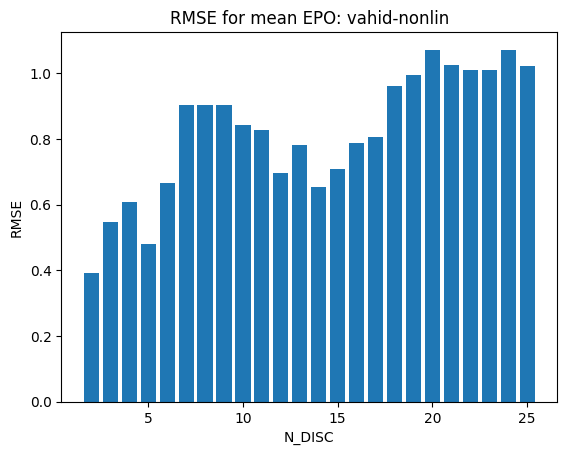

In [10]:
# RMSE calculation on the average EPO

def drf_nonlin(t): return 0.5 * t ** 2 - 2 * t # true dose-response funcion

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_nonlin(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")
plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

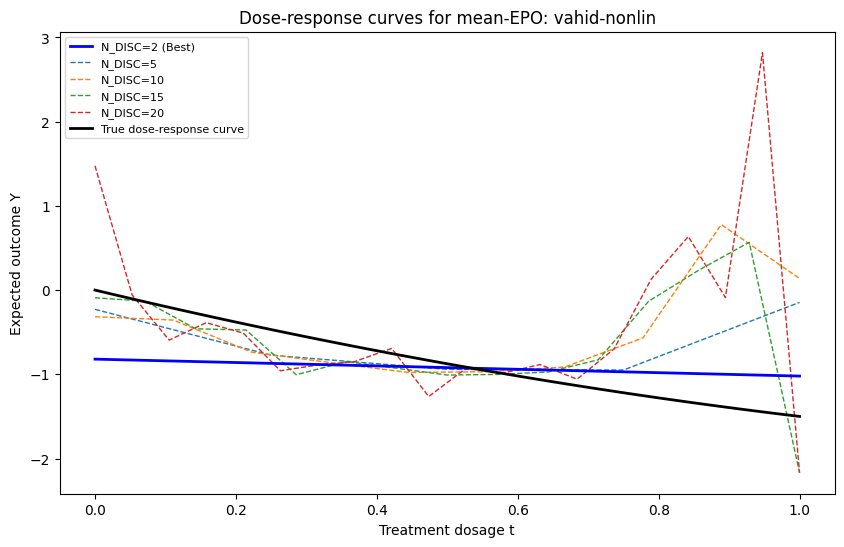

In [11]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 5, 10, 15, 20]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
def nonlin_drf(t): return 0.5 * t ** 2 - 2 * t
t_mesh = np.linspace(0, 1, 100)
y_true = nonlin_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 3: EconML Ex 1 

In [12]:
df = df_econML
data_name = "econ-ML-ex1"
N_max = df.index[-1][0]

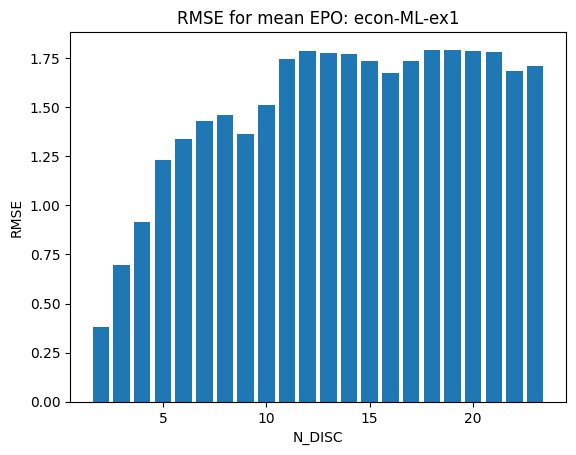

In [13]:
# RMSE calculation on the average EPO

def drf_econML(t): return np.float64(3.211819532711872) * t # true drf; hardcoded the value np.mean(TE) from the DGP

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_econML(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")
plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

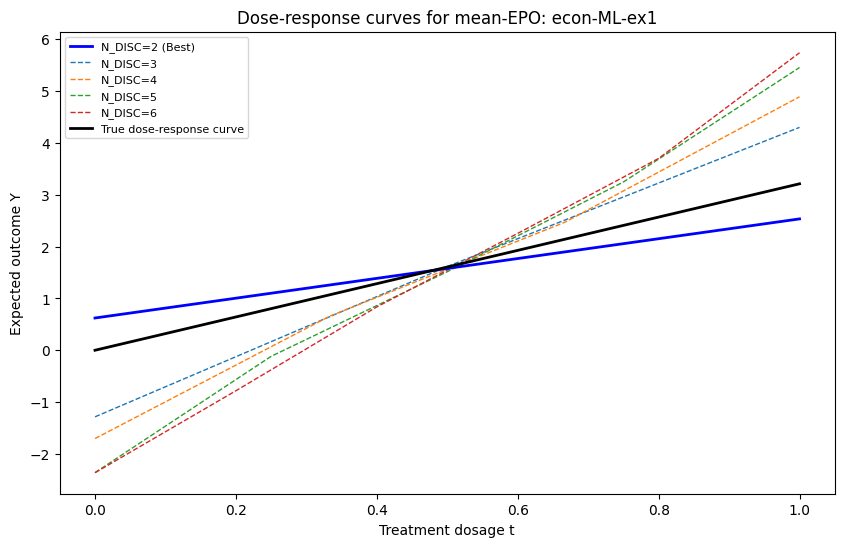

In [14]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 4, 5, 6]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (Ran the DGP and got the coefficient of T separately)
def nonlin_drf(t): return t * 3.21182
t_mesh = np.linspace(0, 1, 100)
y_true = nonlin_drf(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Dataset 4: Debt loss

In [15]:
df = df_debt
data_name = "debt"
N_max = df.index[-1][0]

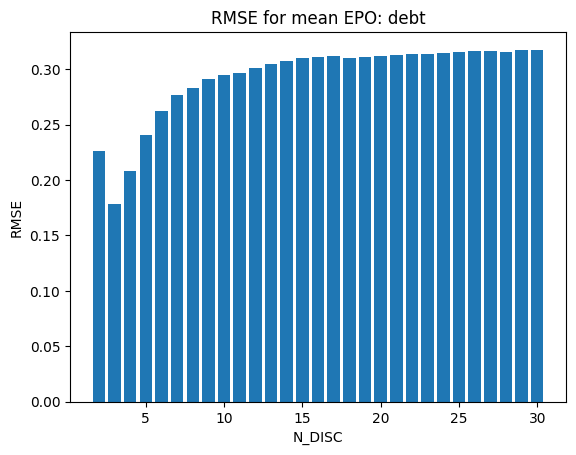

In [16]:
# RMSE calculation on the average EPO

# To get drf_debt (true dose-response), need to re-do DGP
import sys
sys.path.append("../../../my-work/Week_11-17/scripts")
from debt_loss_dgp import DebtDGP, TREATMENT, OUTCOME
generator = DebtDGP()
n = 15000
df_2 = generator.generate_random_financial_data(n) # df name already taken
generator.fit_scalers(df_2)
df_2[TREATMENT] = generator.generate_treatment(df_2, noise=True, noise_scale=0.0, treament_noise_std=0.07)
df_2[OUTCOME + "_probs"], df_2[OUTCOME] = generator.calculate_outcome_probability(df_2, df_2[TREATMENT])
step = 1e-2
bin_edges = np.arange(0, 1+step, step)
real_dose_response = generator.compute_causal_effects(df_2, bin_edges, "ate")
# True dose-response function
y_true_f = interp1d(bin_edges, real_dose_response)
def drf_debt(t): return y_true_f(t)

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_debt(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")
plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

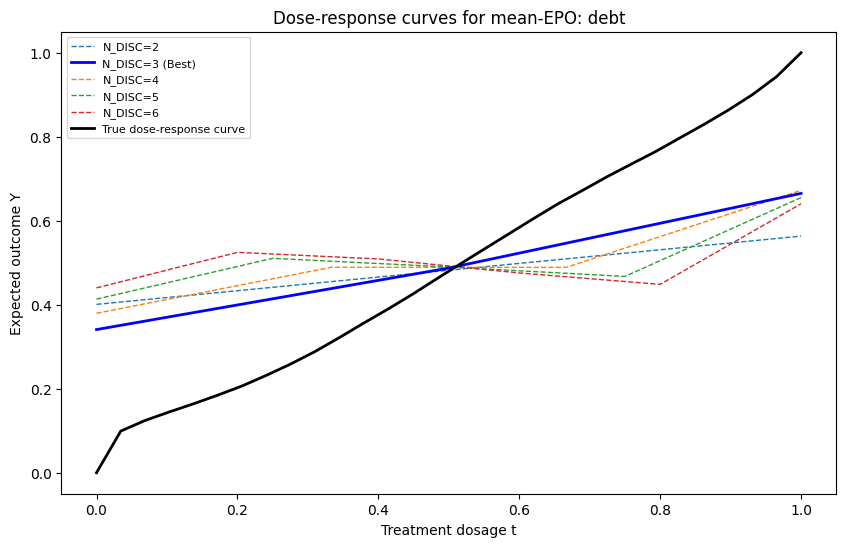

In [17]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 4, 5, 6]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (approximated by df.loc[[30]]["true_effect"])
y_true = df.loc[[30]]["true_effect"].values
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()

## Example 5: ADMIT synthetic dataset

In [18]:
df = df_admit
data_name = "ADMIT-synthetic"
N_max = df.index[-1][0]

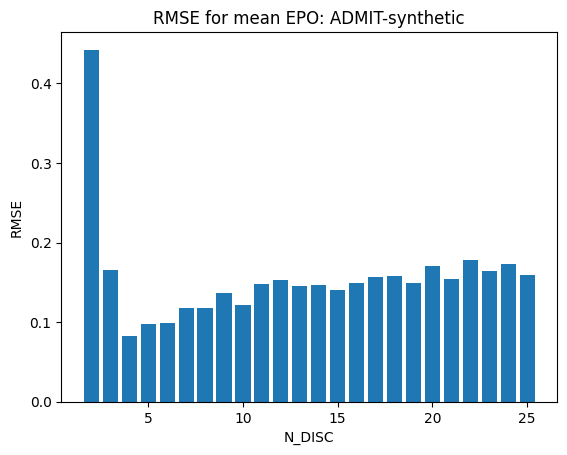

In [19]:
# RMSE calculation on the average EPO

# To get drf_ADMIT (the true dose-response), need to re-do DGP
def sigmoid(t): return 1. / (1. + np.exp(-1. * t))
n, d = 2000, 6
X = np.random.uniform(-1, 1, (n, d))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]
x4 = X[:, 3]
x5 = X[:, 4]
x6 = X[:, 5]
# Generate treatment 
mu_1 =  (10. * np.sin(np.maximum(x1, np.maximum(x2, x3))) + np.maximum(x3, np.maximum(x4, x5))**3)/(1. + (x1 + x5)**2) + np.sin(0.5 * x3) * (1. + np.exp(x4 - 0.5 * x3)) + x3**2 + 2. * np.sin(x4) + 2.*x5 - 6.5
T = np.random.normal(mu_1, 0.5)
T = sigmoid(T)
# Generate outcomes
mu_2 = np.cos(2 * np.pi * (T - 0.5)) * (T ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
Y = np.random.normal(mu_2, 0.5)
# Generated expected potential outcomes empirically
treatment_doses = np.linspace(0, 1, 100)
effects = []
for t in treatment_doses:
    T_intervention = t * np.ones(T.shape)
    mu_2_intervention = np.cos(2 * np.pi * (T_intervention - 0.5)) * (T_intervention ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
    effects.append(mu_2_intervention.mean())
effects = np.array(effects)
drf_ADMIT = interp1d(treatment_doses, effects) # true dose-reponse

rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    drf_N_pred_pts = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    t_vals = np.linspace(0, 1, N_DISC)
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts)
    y_pred = drf_N_pred(rmse_calc_t_mesh)
    y_true = drf_ADMIT(rmse_calc_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{date_string}.csv") # save df
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")
plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{date_string}.png")

plt.show()

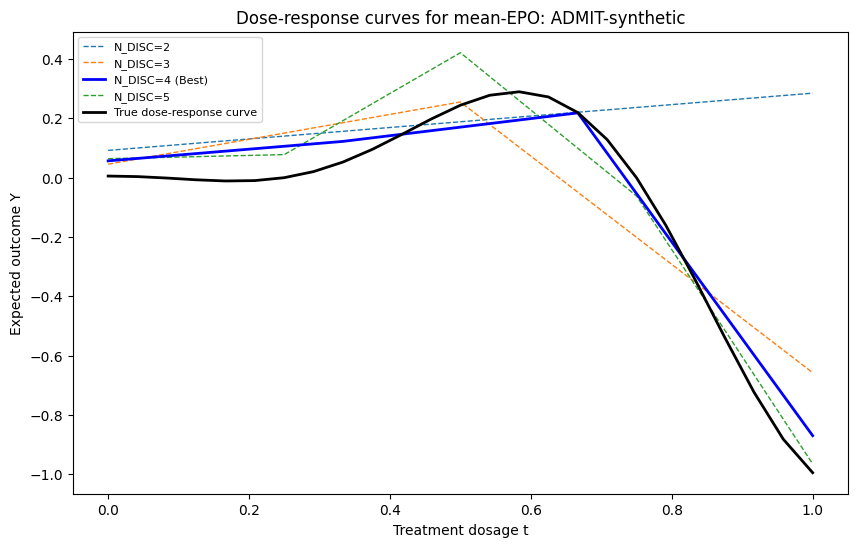

In [20]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 4, 5]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (approximated by df.loc[[25]]["true_effect"])
y_true = df.loc[[25]]["true_effect"].values
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)
plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{date_string}.png")

plt.show()